# Data Preparation

In [10]:
import torchvision
import torch 
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 
import numpy as np 
from PIL import Image
import os

In [11]:
# Point to dataset paths

RAW_DATA_ROOT = r'C:\Users\Admin\CSC173-DeepCV-Reambonanza\csc173-deepcv-final-proj\dataset\split'

In [12]:
print(os.path.exists(RAW_DATA_ROOT))

True


In [13]:
# Path where the transformed images will be saved
SAVE_DATA_ROOT = '../dataset/transformed_dataset' 
os.makedirs(SAVE_DATA_ROOT, exist_ok=True)

In [14]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

# Preprocessing pipeline for training data
train_save_transforms = transforms.Compose([
    # Powerful augmentation that replaces simple Resize in most cases
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),

    # transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), 
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),

    # Geometric Augmentations (Rotation and Shift)
    # Allows up to 15 degrees rotation and 10% translation/shift
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.GaussianBlur(kernel_size=(3, 7), sigma=(0.1, 2.0)),
    transforms.RandomGrayscale(p=0.05)
])

# Preprocessing pipeline for validation and test data
val_test_save_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
])


In [15]:
# Loads the newly saved images and prepares them for display.
view_transforms = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std)) 
])

In [16]:
# Saving function

def save_transformed_images(raw_path, save_path, transform_pipeline):
    """Loads raw images, applies transformations, and saves them to disk."""
    
    # We use os.path.normpath to ensure consistent path separators (\ vs /)
    normalized_raw_path = os.path.normpath(raw_path) 
    
    # ImageFolder loads the paths and class indices from your raw data
    raw_dataset = ImageFolder(root=normalized_raw_path)
    class_names = raw_dataset.classes

    print(f"\nStarting transformation and saving for: {os.path.basename(normalized_raw_path)}")
    
    for i, (image_path, label_index) in enumerate(raw_dataset.imgs):
        
        class_name = class_names[label_index]
        target_dir = os.path.join(save_path, os.path.basename(normalized_raw_path), class_name)
        os.makedirs(target_dir, exist_ok=True)
        
        original_filename = os.path.basename(image_path)
        new_filename = f"{i}_{original_filename.replace('.', '_proc.')}"
        save_file_path = os.path.join(target_dir, new_filename)
        
        try:
            # 1. Load the image
            img = Image.open(image_path).convert('RGB')
            
            # 2. Apply the defined transformations (returns PIL Image)
            transformed_img = transform_pipeline(img)
            
            # 3. Save the image to the new folder
            transformed_img.save(save_file_path, "JPEG") 
            
        except Exception as e:
            # This 'pass' is fine for quick run, but if images are missing, check the class folders in RAW_DATA_ROOT
            pass 
            
    print(f"Finished. Saved {len(raw_dataset.imgs)} images to: {os.path.normpath(save_path)}")

In [17]:
# load images from the NEWLY SAVED folder and display them.

def show_transformed_images(dataset):
    loader = torch.utils.data.DataLoader(dataset, batch_size=6, shuffle=True)
    batch = next(iter(loader))
    images, labels = batch

    # Need to clip and re-order the tensor for correct display with Matplotlib
    grid = torchvision.utils.make_grid(images, nrow=3)
    
    # Convert tensor (C, H, W) to numpy (H, W, C) for display
    np_img = np.transpose(grid.numpy(), (1, 2, 0))
    
    # Un-normalize the image so it looks correct (otherwise it's dark/green)
    unnormalize = transforms.Normalize(
        mean=[-m/s for m, s in zip(mean, std)],
        std=[1/s for s in std]
    )
    unnormalized_img = unnormalize(grid).permute(1, 2, 0).clip(0, 1)

    plt.figure(figsize=(10,10))
    plt.imshow(unnormalized_img)
    plt.title("Sample of Newly Saved and Transformed Images")
    plt.axis('off')
    plt.show()
    print('Labels:', labels)


Starting transformation and saving for: train
Finished. Saved 143 images to: ..\dataset\transformed_dataset

Starting transformation and saving for: val
Finished. Saved 28 images to: ..\dataset\transformed_dataset

Starting transformation and saving for: test
Finished. Saved 36 images to: ..\dataset\transformed_dataset


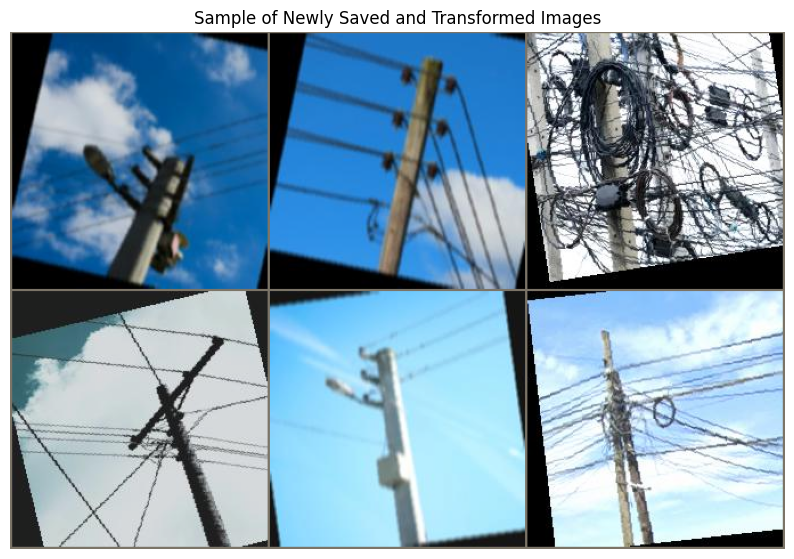

Labels: tensor([2, 2, 1, 2, 2, 0])
SUCCESS: All preprocessed images are now correctly saved inside: ..\dataset\transformed_dataset


In [18]:
# MAIN EXECUTION

if __name__ == "__main__":
    
    # A. SAVE THE PROCESSED IMAGES TO DISK
    
    # Process Training Data (uses augmented pipeline: train_save_transforms)
    save_transformed_images(
        os.path.join(RAW_DATA_ROOT, 'train'), 
        os.path.join(SAVE_DATA_ROOT), # Save to the main SAVE_DATA_ROOT
        train_save_transforms
    )

    # Process Validation Data (uses non-augmented pipeline: val_test_save_transforms)
    save_transformed_images(
        os.path.join(RAW_DATA_ROOT, 'val'), 
        os.path.join(SAVE_DATA_ROOT), 
        val_test_save_transforms
    )

    # Process Test Data (uses non-augmented pipeline: val_test_save_transforms)
    save_transformed_images(
        os.path.join(RAW_DATA_ROOT, 'test'), 
        os.path.join(SAVE_DATA_ROOT), 
        val_test_save_transforms
    )

    # B. SHOW A SAMPLE OF THE SAVED IMAGES
    
    saved_train_path_full = os.path.join(SAVE_DATA_ROOT, 'train')
    
    # Create the dataset using the saved images and the 'view_transforms'
    train_view_dataset = torchvision.datasets.ImageFolder(
        root=saved_train_path_full, 
        transform=view_transforms
    )
    
    # Show the transformed images
    show_transformed_images(train_view_dataset)

    print(f"SUCCESS: All preprocessed images are now correctly saved inside: {os.path.normpath(SAVE_DATA_ROOT)}")